# HivePlot Demo
Explorativer Plot mit hiveplotlib auf einem sample_graph.

In [2]:
import sys
sys.path.insert(0, '../')  # damit src/ gefunden wird

from src.graphs import sample_graph
import networkx as nx

G = sample_graph(sizes=(10, 10, 10))
print(f"Knoten: {G.number_of_nodes()}, Kanten: {G.number_of_edges()}")

Knoten: 30, Kanten: 300


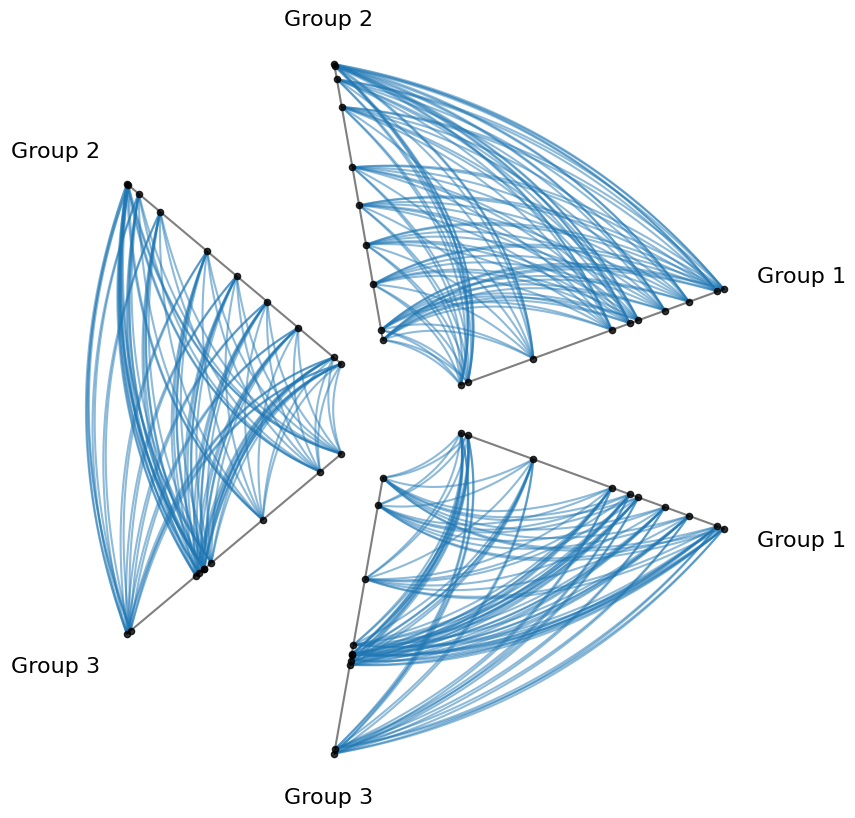

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from hiveplotlib import HivePlot
from hiveplotlib.converters import networkx_to_nodes_edges

nodes, edges = networkx_to_nodes_edges(G)

partition_variable = nodes.create_partition_variable(
    data_column="subset",
    cutoffs=3,
    labels=["Group 1", "Group 2", "Group 3"],
)

rng = np.random.default_rng(0)
nodes.data["val"] = rng.uniform(size=len(nodes.data))

hp = HivePlot(
    nodes=nodes,
    edges=edges,
    partition_variable=partition_variable,
    sorting_variables="val",
    repeat_axes=True,
)
fig, ax = hp.plot(color="C0")
plt.show()